# 04 - Avaliação e exportação para o Power BI

Um único período de teste pode enganar. Aqui repetimos o experimento com cortes em dez/2021,
dez/2022 e dez/2023 (cada um testando os 12 meses seguintes), escolhemos o modelo final e geramos os
arquivos do dashboard.

Além dos modelos de ML do notebook 03, entram os modelos clássicos de série temporal (SARIMA e
Holt-Winters, um por item, detalhados no notebook 05) e a **combinação** gradient boosting + SARIMA
(média das duas previsões). A avaliação leva uns 4 minutos por causa dos modelos por item.

Equivale a rodar `train_model`, `evaluate` e `predict_model` pela linha de comando.

In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid")

from src.config import POWERBI_DIR, FIGURES_DIR
from src.models import train_model, evaluate, predict_model

In [2]:
train_model.main()
evaluate.main()

22:07:20 | INFO | src.models.train_model | Treino: 5897 linhas (alvo até 2024-12-01) | Teste: 884 linhas (base a partir de 2024-12-01)


22:07:20 | INFO | src.models.train_model | ridge treinado


22:07:25 | INFO | src.models.train_model | random_forest treinado


22:07:26 | INFO | src.models.train_model | gradient_boosting treinado


22:07:57 | INFO | src.models.evaluate | sarima: 884 previsões


...

22:10:04 | INFO | src.models.evaluate | Backtest corte 2022-12-01: 720 linhas de teste


22:10:33 | INFO | src.models.evaluate | sarima: 720 previsões


22:11:01 | INFO | src.models.evaluate | ets: 720 previsões


22:11:01 | INFO | src.models.evaluate | Backtest corte 2023-12-01: 720 linhas de teste


22:11:01 | INFO | src.models.evaluate | Arquivos de avaliação salvos em data/processed/powerbi/


## Backtest

In [3]:
met = pd.read_csv(POWERBI_DIR / "metricas_modelos.csv")
tab = met.pivot(index="modelo", columns="corte", values="wape").round(2)
tab["media"] = tab.mean(axis=1).round(2)
tab.sort_values("media")

corte,2021-12-01,2022-12-01,2023-12-01,2024-12-01,media
modelo,,,,,
combinado,4.79,3.75,2.81,3.86,3.80
gradient_boosting,4.82,3.85,2.87,3.97,3.88
random_forest,4.98,3.84,2.96,3.92,3.92
ingenuo,4.97,3.90,3.16,4.38,4.10
sarima,5.26,3.96,3.17,4.12,4.13
ridge,5.28,4.14,3.08,4.32,4.20
ets,5.49,4.11,3.16,4.27,4.26
sazonal_ingenuo,6.37,6.14,4.29,5.07,5.47


In [4]:
met.pivot(index="modelo", columns="corte", values="ganho_vs_ingenuo_pct").round(1)

corte,2021-12-01,2022-12-01,2023-12-01,2024-12-01
modelo,,,,
combinado,3.7,4.0,11.1,11.8
ets,-10.3,-5.3,-0.1,2.3
gradient_boosting,3.1,1.4,9.2,9.3
ingenuo,0.0,0.0,0.0,0.0
random_forest,-0.1,1.6,6.2,10.5
ridge,-6.2,-6.2,2.5,1.3
sarima,-5.8,-1.5,-0.5,6.0
sazonal_ingenuo,-28.0,-57.3,-35.9,-15.9


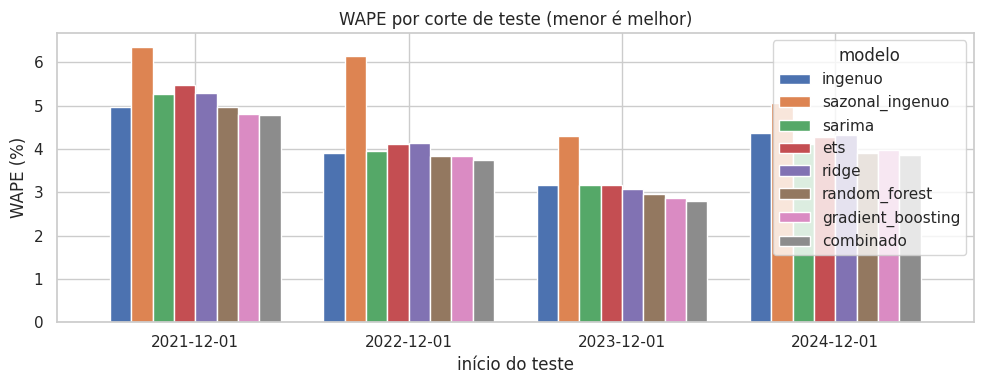

In [5]:
ordem = ["ingenuo", "sazonal_ingenuo", "sarima", "ets", "ridge", "random_forest", "gradient_boosting", "combinado"]
ax = met.pivot(index="corte", columns="modelo", values="wape")[ordem].plot(kind="bar", figsize=(10, 4), width=0.8)
ax.set_title("WAPE por corte de teste (menor é melhor)")
ax.set_ylabel("WAPE (%)")
ax.set_xlabel("início do teste")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_backtest_wape.png", dpi=120)

Leitura:

- A **combinação gradient boosting + SARIMA** tem o menor WAPE médio (3,80% contra 4,10% do ingênuo, ganho de ~7%) e ganha do ingênuo **nos quatro cortes**.
- O **gradient boosting** sozinho vem logo atrás (3,88%) e também ganha nos quatro, mas por muito pouco no corte de dez/2022 (1,4%). Esse corte testa 2023, o ano em que a inflação desacelerou de repente: as features de tendência apontavam para continuar subindo.
- **SARIMA e ETS** sozinhos ficam no nível do ingênuo (4,13% e 4,26%). Olham só o histórico de cada item.
- O **random forest** é o que ganha do ingênuo no maior número de séries do teste principal (77%), mas empata com ele no corte de 2021. Menos estável.
- **Ridge** perde para o ingênuo em dois cortes: a relação é não linear (sazonalidade só importa para algumas categorias).
- **Sazonal ingênuo** é sempre o pior. Repetir o ano anterior inteiro carrega junto os choques daquele ano.

## Modelo final e previsão

In [6]:
predict_model.main()
fut = pd.read_csv(POWERBI_DIR / "previsao_futura.csv", parse_dates=["data_base", "data_alvo"])
fut.groupby("categoria")["variacao_prevista_pct"].median().sort_values().round(2)

22:11:02 | INFO | src.models.predict_model | WAPE médio nos cortes:
modelo
combinado            3.800
gradient_boosting    3.876
random_forest        3.925
sarima               4.129
ridge                4.207
ets                  4.259


22:11:02 | INFO | src.models.predict_model | Modelo final: combinado


22:11:02 | WARNING | src.features.build_features | Sem previsão (dados recentes incompletos): Lettuce, romaine


22:11:40 | INFO | src.models.predict_model | Previsão para 59 séries (alvo mais comum: 2026-10-01)


22:11:41 | INFO | src.models.predict_model | dim_item (74), fato_precos (8970) e sazonalidade exportados


categoria
Energia           -4.03
Hortaliças        -1.49
Padaria e grãos   -0.42
Carne bovina      -0.08
Suínos e frios     0.24
Laticínios         0.25
Aves               0.26
Bebidas            0.48
Mercearia          0.79
Frutas             0.94
Ovos               3.52
Name: variacao_prevista_pct, dtype: float64

In [7]:
cols = ["item", "preco_base", "preco_previsto", "faixa_inferior", "faixa_superior", "variacao_prevista_pct"]
pd.concat([fut.nsmallest(5, "variacao_prevista_pct"), fut.nlargest(5, "variacao_prevista_pct")])[cols]

,item,preco_base,preco_previsto,faixa_inferior,faixa_superior,variacao_prevista_pct
33,Automotive diesel fuel,5.077,4.636,4.405,5.990,-8.68
39,"Gasoline, unleaded regular",4.094,3.857,3.665,4.983,-5.80
44,"Gasoline, all types",4.242,4.047,3.845,5.229,-4.59
42,"Gasoline, unleaded midgrade",4.583,4.388,4.169,5.669,-4.25
22,"Gasoline, unleaded premium",5.027,4.835,4.594,6.247,-3.81
20,"Strawberries, dry pint",2.404,2.889,2.735,3.067,20.18
2,"Oranges, Navel",1.540,1.686,1.596,1.790,9.48
51,"Eggs, grade A, large",2.189,2.266,1.695,2.386,3.52
25,"Butter, stick",3.922,4.022,3.775,4.155,2.54
8,All Other Pork (Excluding Canned Ham and Lunch...,3.671,3.758,3.597,3.850,2.37


## Arquivos gerados para o Power BI

In [8]:
for arq in sorted(POWERBI_DIR.glob("*.csv")):
    print(f"{arq.name:32s} {len(pd.read_csv(arq)):>6} linhas")

dim_item.csv                         74 linhas
fato_precos.csv                    8970 linhas
metricas_modelos.csv                 32 linhas
metricas_por_categoria.csv           88 linhas
metricas_por_item.csv               480 linhas
previsao_futura.csv                  59 linhas
previsoes_teste.csv                7072 linhas
sazonalidade.csv                    888 linhas


## Conclusões

1. Prever preço de alimento 3 meses à frente é difícil: o ingênuo já erra só ~4%. O modelo final (combinação gradient boosting + SARIMA) reduz esse erro em ~7% na média dos quatro cortes e ~12% no teste mais recente. Ganho modesto, mas consistente: positivo em todos os cortes.
2. O ganho está concentrado onde há estrutura: **frutas** (sazonalidade, -46% de erro), **ovos** (-19%), **suínos** (-15%), **hortaliças** (-14%) e **carne bovina** (-13%). Em categorias paradas (aves, bebidas, laticínios, padaria) o ingênuo é melhor ou igual; no dashboard isso aparece por categoria.
3. A previsão para out/2026 indica **queda de energia** (diesel -9%, gasolina -6%) depois da alta do primeiro semestre, e alta sazonal de morango e laranja. A faixa de energia é assimétrica (até +29% acima da previsão) porque no teste os modelos subestimaram justamente essa alta: tendem a apostar em reversão.
4. Limitações: preços nominais (sem desconto da inflação), média nacional, e a faixa é empírica (quantis do erro no teste), não um intervalo de confiança formal.